In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from sklearn.model_selection import train_test_split
import tensorflow as tf
import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import cv2
from mpl_toolkits.axes_grid1 import ImageGrid
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.optimizers import Adam

In [2]:
import os
import pandas as pd

Lung_Opacity = r"D:\gradution project\Lung X-Ray Image\Lung_Opacity"
Normal = r"D:\gradution project\Lung X-Ray Image\Normal"
Viral_Pneumonia = r"D:\gradution project\Lung X-Ray Image\Viral Pneumonia"

file_p = []
labels = []

dict_lists = [Normal, Lung_Opacity, Viral_Pneumonia]
class_labels = ['Normal', 'Lung Opacity', 'Viral Pneumonia']

for i, dir_path in enumerate(dict_lists):
    if not os.path.exists(dir_path):
        print(f"path is not exist {dir_path}")
        continue

    list_f = os.listdir(dir_path)
    for name in list_f:
        fpath = os.path.join(dir_path, name)
        file_p.append(fpath)
        labels.append(class_labels[i])

df = pd.DataFrame({
    'filepaths': file_p,
    'labels': labels
})

print(df.head())


                                           filepaths  labels
0  D:\gradution project\Lung X-Ray Image\Normal\1...  Normal
1  D:\gradution project\Lung X-Ray Image\Normal\1...  Normal
2  D:\gradution project\Lung X-Ray Image\Normal\1...  Normal
3  D:\gradution project\Lung X-Ray Image\Normal\1...  Normal
4  D:\gradution project\Lung X-Ray Image\Normal\1...  Normal


In [3]:
df.head()

,filepaths,labels
0,D:\gradution project\Lung X-Ray Image\Normal\1...,Normal
1,D:\gradution project\Lung X-Ray Image\Normal\1...,Normal
2,D:\gradution project\Lung X-Ray Image\Normal\1...,Normal
3,D:\gradution project\Lung X-Ray Image\Normal\1...,Normal
4,D:\gradution project\Lung X-Ray Image\Normal\1...,Normal


In [4]:
train_df, test_df = train_test_split(df, test_size=0.25, random_state=42,stratify=df.labels)
train_df, val_df = train_test_split(train_df, test_size=0.15, random_state=42,stratify=train_df.labels)
print(train_df.shape)
print(test_df.shape)
print(val_df.shape)

(2215, 2)
(869, 2)
(391, 2)


In [5]:
def enhance_image(image):
    image = cv2.addWeighted(image, 1.5, image, -0.5, 0)

    kernel = np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]])
    image = cv2.filter2D(image, -1, kernel)

    hue = image[:, :, 0]
    saturation = image[:, :, 1]
    value = image[:, :, 2]
    value = np.clip(value * 1.25, 0, 255)

    image[:, :, 2] = value

    return image

In [6]:
image_gen = ImageDataGenerator(
    rescale=1./255,
    preprocessing_function=lambda image: enhance_image(image))
train = image_gen.flow_from_dataframe(dataframe= train_df,x_col="filepaths",y_col="labels",
                                      target_size=(256,256),
                                      color_mode='rgb',
                                      class_mode="categorical", 
                                      batch_size=32,
                                      shuffle=False            
                                     )
test = image_gen.flow_from_dataframe(dataframe= test_df,x_col="filepaths", y_col="labels",
                                     target_size=(256,256),
                                     color_mode='rgb',
                                     class_mode="categorical",
                                     batch_size=32,
                                     shuffle= False
                                    )
val = image_gen.flow_from_dataframe(dataframe= val_df,x_col="filepaths", y_col="labels",
                                    target_size=(256,256),
                                    color_mode= 'rgb',
                                    class_mode="categorical",
                                    batch_size=32,
                                    shuffle=False
                                   )

Found 2215 validated image filenames belonging to 3 classes.
Found 869 validated image filenames belonging to 3 classes.
Found 391 validated image filenames belonging to 3 classes.


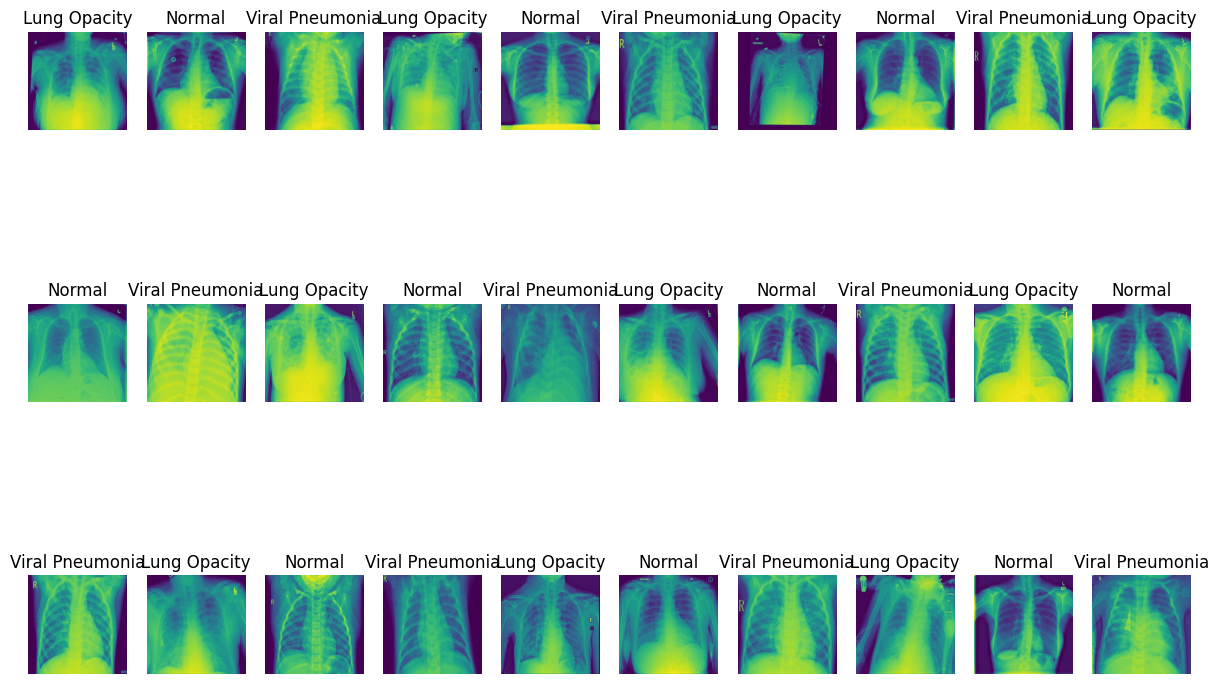

In [7]:
import matplotlib.pyplot as plt

# Define the number of images to display from each class
num_images_per_class = 10

# Get class labels
class_labels = list(train.class_indices.keys())

# Plot images from each class
plt.figure(figsize=(15, 10))
for label in class_labels:
    # Get indices of images belonging to the current class
    indices = train_df[train_df['labels'] == label].index
    
    # Randomly sample a subset of indices if there are more than the desired number of images per class
    indices = np.random.choice(indices, min(num_images_per_class, len(indices)), replace=False)
    
    # Plot images
    for i, idx in enumerate(indices):
        plt.subplot(len(class_labels), num_images_per_class, len(class_labels)*i + class_labels.index(label) + 1)
        plt.imshow(plt.imread(train_df.loc[idx, 'filepaths']))  # Load and plot the image
        plt.title(label)
        plt.axis('off')
plt.show()


In [ ]:
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.layers import Dropout
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adamax

# Load pre-trained MobileNet model without the top (fully connected) layers
base_model = MobileNet(weights='imagenet', include_top=False, input_shape=(256, 256, 3),pooling='max')

# Add custom top layers for your specific task
x = base_model.output
x = BatchNormalization(axis= -1, momentum= 0.99, epsilon= 0.001)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.45)(x)
predictions = Dense(3, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

optimizer = Adamax(learning_rate=0.001)  
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(train, epochs=20, validation_data=val)


C:\Users\user\AppData\Local\Temp\ipykernel_21344\1569921032.py:8: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNet(weights='imagenet', include_top=False, input_shape=(256, 256, 3),pooling='max')
C:\Users\user\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 1137s 16s/step - accuracy: 0.7140 - loss: 0.7168 - val_accuracy: 0.5652 - val_loss: 2.2836
Epoch 2/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 271s 4s/step - accuracy: 0.9347 - loss: 0.1674 - val_accuracy: 0.8338 - val_loss: 0.4549
Epoch 3/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 173s 2s/step - accuracy: 0.9792 - loss: 0.0691 - val_accuracy: 0.9003 - val_loss: 0.2764
Epoch 4/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 109s 2s/step - accuracy: 0.9945 - loss: 0.0270 - val_accuracy: 0.9079 - val_loss: 0.3117
Epoch 5/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 106s 2s/step - accuracy: 0.9957 - loss: 0.0172 - val_accuracy: 0.9054 - val_loss: 0.3073
Epoch 6/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 138s 2s/step - accuracy: 1.0000 - loss: 0.0073 - val_accuracy: 0.9130 - val_loss: 0.3008
Epoch 7/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 108s 2s/step - accuracy: 1.0000 - loss: 0.0053 - val_accuracy: 0.9207 - val_loss: 0.3033
Epoch 8/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 112s 2s/step - accuracy: 1.0000 - loss: 0.0035 - val_accuracy: 0.9182 -

In [9]:
loss, accuracy = model.evaluate(test)
print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

28/28 ━━━━━━━━━━━━━━━━━━━━ 18s 640ms/step - accuracy: 0.9311 - loss: 0.3227
Test Loss: 0.3221942186355591
Test Accuracy: 0.9321058392524719


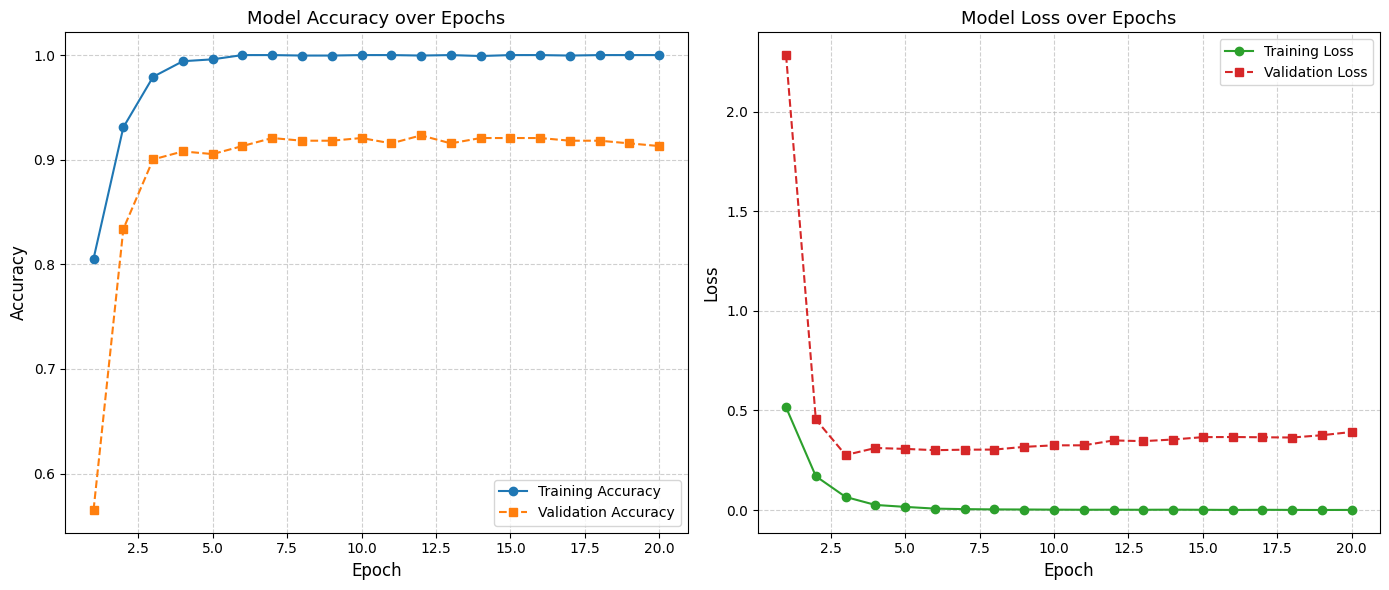

In [10]:
import matplotlib.pyplot as plt

# استخراج البيانات من history
train_accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']
train_loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(train_accuracy) + 1)

# إنشاء الرسم
plt.figure(figsize=(14, 6))

# ====== دقة التدريب والتحقق ======
plt.subplot(1, 2, 1)
plt.plot(epochs, train_accuracy, 'o-', color='#1f77b4', label='Training Accuracy')
plt.plot(epochs, val_accuracy, 's--', color='#ff7f0e', label='Validation Accuracy')
plt.title('Model Accuracy over Epochs', fontsize=13)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# ====== خسارة التدريب والتحقق ======
plt.subplot(1, 2, 2)
plt.plot(epochs, train_loss, 'o-', color='#2ca02c', label='Training Loss')
plt.plot(epochs, val_loss, 's--', color='#d62728', label='Validation Loss')
plt.title('Model Loss over Epochs', fontsize=13)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


28/28 ━━━━━━━━━━━━━━━━━━━━ 11s 351ms/step


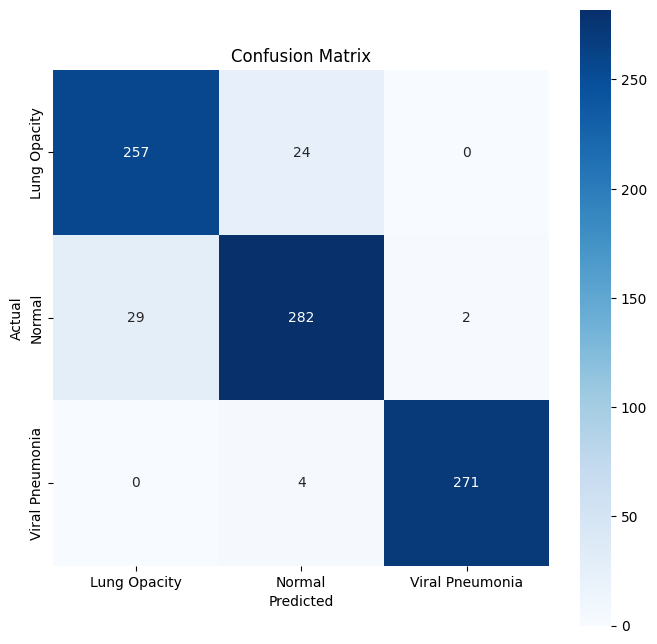

In [11]:
from sklearn.metrics import confusion_matrix
import numpy as np

# Get predictions for the test data
y_pred = model.predict(test)
y_pred_classes = np.argmax(y_pred, axis=1)

# Get true labels for the test data
true_classes = test.classes

# Compute confusion matrix
conf_matrix = confusion_matrix(true_classes, y_pred_classes)

# Plot confusion matrix
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', square=True, 
            xticklabels=test.class_indices.keys(), yticklabels=test.class_indices.keys())
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


In [12]:
import os
import json
from pathlib import Path
import tensorflow as tf
from tensorflow import keras

# ========= API artifacts folder =========
API_ARTIFACTS_DIR = Path(r"D:\gradution project\Lung X-Ray Image\api_artifacts")
API_ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

# ========= File names =========
MODEL_PATH = API_ARTIFACTS_DIR / "mobilenet_lung_model.keras"
CLASS_NAMES_PATH = API_ARTIFACTS_DIR / "class_names.json"
CONFIG_PATH = API_ARTIFACTS_DIR / "config.json"

# ========= 1) Save model in recommended Keras format =========
# الصيغة الموصى بها حاليًا هي .keras
model.save(MODEL_PATH)

# ========= 2) Save class names in correct order =========
# الأفضل دائمًا أخذ الترتيب من generator نفسه
class_names = list(train.class_indices.keys())

with open(CLASS_NAMES_PATH, "w", encoding="utf-8") as f:
    json.dump(
        {"class_names": class_names},
        f,
        ensure_ascii=False,
        indent=2
    )

# ========= 3) Save config needed by API =========
config = {
    "img_size": [256, 256],
    "color_mode": "rgb",
    "class_mode": "categorical",
    "num_classes": len(class_names),
    "model_file": "mobilenet_lung_model.keras",
    "class_names_file": "class_names.json",
    "preprocessing": {
        "resize": [256, 256],
        "convert_to_rgb": True,
        "enhance_image": True,
        "rescale": 1.0 / 255.0
    }
}

with open(CONFIG_PATH, "w", encoding="utf-8") as f:
    json.dump(config, f, ensure_ascii=False, indent=2)

# ========= 4) Sanity check: reload model =========
reloaded_model = keras.models.load_model(MODEL_PATH, compile=False)

print("API artifacts saved successfully:")
print("-", MODEL_PATH)
print("-", CLASS_NAMES_PATH)
print("-", CONFIG_PATH)
print("Class order:", class_names)
print("Reload test passed:", reloaded_model is not None)

API artifacts saved successfully:
- D:\gradution project\Lung X-Ray Image\api_artifacts\mobilenet_lung_model.keras
- D:\gradution project\Lung X-Ray Image\api_artifacts\class_names.json
- D:\gradution project\Lung X-Ray Image\api_artifacts\config.json
Class order: ['Lung Opacity', 'Normal', 'Viral Pneumonia']
Reload test passed: True
